# Clustering of Superconductor data (3D_SC)

In [ ]:
from __future__ import print_function, division   
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score

import optuna
import umap
from sklearn.metrics import silhouette_score

import lightgbm as lgb 
from scipy.stats import randint, poisson
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA

from sklearn.metrics import mean_squared_error, log_loss
from lightgbm import early_stopping
import time

SavePlots = False

import sys
sys.path.insert(1, '/Users/fbnielsen/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Uni OneDrive/4 år/AMAS')
 
import amasF as F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

from iminuit.cost import UnbinnedNLL
from iminuit import Minuit, cost

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 16,
    "axes.grid": True,
    "grid.alpha": 0.2
})

import re

def contains_element(formula, element):
    # Match element symbol not followed by a lowercase letter (avoids e.g. 'Co' matching 'C')
    pattern = r'(?<![A-Z])' + element + r'(?![a-z])'
    return bool(re.search(pattern, str(formula)))

## Data and CIF 

In [18]:
data_3dsc = pd.read_csv('/Users/fbnielsen/Desktop/3DSC/3DSC_MP.csv', skiprows=1)

formula = data_3dsc['formula_sc']

feature_cols = [
    #'tc',      dont include in clustering     
    'lata_2', 'latb_2', 'latc_2',               
    'band_gap_2',                               
    'density_2',                                
    'e_above_hull_2',                            
    'formation_energy_per_atom_2',              
    'energy_per_atom_2',                         
    'efermi_2',                                 
    'final_energy_2',
    'is_magnetic_2',
    'exchange_symmetry_2',
    'num_magnetic_sites_2',
    'total_magnetization_2',                    
    'cell_volume_2',                             
    'num_elements_sc',                          
    'nsites_2',                                 
    'cubic', 'hexagonal', 'monoclinic', 'orthorhombic',
    'tetragonal', 'triclinic', 'trigonal',
    'primitive', 'base-centered', 'body-centered', 'face-centered',
]

df = data_3dsc[feature_cols].copy()

tc = data_3dsc['tc']
sc_class = data_3dsc['sc_class']

tc.to_csv('tc_3dsc.csv')


In [19]:
import ast

# Parse the string dicts into real dicts
formulas = data_3dsc['unit_cell_formula_2'].apply(ast.literal_eval)

# Get all unique elements across the whole dataset
all_elements = sorted(set(el for formula in formulas for el in formula.keys()))
print(f"Found {len(all_elements)} unique elements")

# Create one column per element, 0 if not present
element_df = pd.DataFrame(
    [{el: formula.get(el, 0.0) for el in all_elements} for formula in formulas],
    index=df.index
)

# Add to your dataframe
df_wchem = pd.concat([df, element_df], axis=1)

print(element_df.head())
print(f"New shape: {df_wchem.shape}")


Found 82 unique elements
    Ag   Al   As   Au    B   Ba   Be   Bi   Br    C  ...   Ti   Tl   Tm    U  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0  0.0  4.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   

     V    W    Y   Yb   Zn   Zr  
0  0.0  0.0  0.0  0.0  0.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  
3  0.0  0.0  0.0  0.0  0.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 82 columns]
New shape: (5773, 110)


In [20]:
df_wchem.to_csv('df_wchem.csv')

## CIF INFO

In [21]:
import torch
from torch_geometric.data import Data
from pymatgen.core import Structure

# Gaussian basis expansion for bond distances (like CGCNN)
def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
    filters = np.linspace(dmin, dmax, steps)
    sigma = (dmax - dmin) / steps
    return np.exp(-((distances[:, None] - filters[None, :]) * 2) / sigma * 2)

def get_atom_features(structure):
    features = []
    for site in structure:
        
        if site.is_ordered:
            elem = site.specie
            features.append([
                float(elem.Z),
                float(elem.atomic_mass),
                float(elem.atomic_radius) if elem.atomic_radius else 0.0,
                float(elem.X) if elem.X else 0.0,          # electronegativity
                float(elem.row),                            # period in periodic table
                float(elem.group),                         # group in periodic table
                1.0,                                        # occupancy (fully occupied)
                0.0,                                        # disorder: 0 = pure site
            ])
        else:
            Z, mass, radius, X, row, group = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
            # measure of disorder (like entropy)
            occupancies = list(site.species.values())
            disorder = -sum(o * np.log(o + 1e-9) for o in occupancies)
            
            for elem, occ in site.species.items():
                Z      += occ * float(elem.Z)
                mass   += occ * float(elem.atomic_mass)
                radius += occ * (float(elem.atomic_radius) if elem.atomic_radius else 0.0)
                X      += occ * (float(elem.X) if elem.X else 0.0)
                row    += occ * float(elem.row)
                group  += occ * float(elem.group)

            features.append([Z, mass, radius, X, row, group,
                              max(occupancies),  # dominant occupancy
                              disorder])         # site disorder

    return np.array(features, dtype=np.float32)

def structure_to_graph(structure, target, cutoff=8.0):
    # Node features
    atom_feats = get_atom_features(structure)
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Find neighbors within cutoff
    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)

    edge_src, edge_dst, edge_distances = [], [], []
    for i, neighbors in enumerate(all_neighbors):
        for neighbor in neighbors:
            edge_src.append(i)
            edge_dst.append(neighbor[2])       # index of neighbor atom
            edge_distances.append(neighbor[1]) # distance

    edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

    # Edge features: Gaussian expanded distances
    distances = np.array(edge_distances)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)
    #print(distances, edge_attr)
    # Target value
    y = torch.tensor([target], dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data

path_red = '/Users/fbnielsen/Desktop/3DSC/3DSC/superconductors_3D'
structure = Structure.from_file(path_red +'/' + data_3dsc.loc[0,'cif'])
graph = structure_to_graph(structure, target=2.64, cutoff=8.0)
print(structure.get_all_neighbors(8, include_index=True))

# Average atom features across all atoms → one vector per material
graph = structure_to_graph(structure, target=tc, cutoff=8.0)
mean_atom_feats = graph.x.numpy().mean(axis=0)  # shape (8,)
all_graph_feats = []

[[PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-0.5469, -3.057, -1.382) [-0.25, -0.75, -0.5], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-2.934, -1.019, -1.382) [-0.75, -0.25, -0.5], PeriodicNeighbor: Ge1 (Ge) (-1.29, -1.511, -3.259) [-0.3706, -0.3706, -0.7411], PeriodicNeighbor: Sr0 (Sr) (-3.481, -4.076, -2.764) [-1.0, -1.0, -1.0], PeriodicNeighbor: Ge1 (Ge) (-2.191, -2.566, -5.535) [-0.6294, -0.6294, -1.259], PeriodicNeighbor: Ge1 (Ge) (-0.6433, -5.587, -1.625) [-0.3706, -1.371, -0.7411], PeriodicNeighbor: Ge1 (Ge) (-1.544, -6.642, -3.902) [-0.6294, -1.629, -1.259], PeriodicNeighbor: Ge1 (Ge) (-5.417, -1.511, -1.625) [-1.371, -0.3706, -0.7411], PeriodicNeighbor: Ge1 (Ge) (-6.318, -2.566, -3.902) [-1.629, -0.6294, -1.259], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-0.5469, -3.057, 4.649) [-0.25, -0.75, 0.5], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-2.934, -1.019, 4.649) [-0.75, -0.25, 0.5], PeriodicNeighbor: Ge1 (Ge) (-1.29, -1.511, 2.772) [-0.3706, -0.3706, 0.2589], PeriodicNeighbor: G

In [22]:
for i, row in data_3dsc.iterrows():
    try:
        structure = Structure.from_file(path_red + '/' + row['cif'])
        graph = structure_to_graph(structure, target=row['tc'], cutoff=8.0)
        feats = graph.x.numpy()
        vector = np.concatenate([
            feats.mean(axis=0),
            feats.std(axis=0),
            feats.min(axis=0),
            feats.max(axis=0)
        ])  # shape (32,)
    except Exception as e:
        print(f"Failed on row {i}: {e}")
        vector = np.zeros(32)  # placeholder for failed structures
    
    all_graph_feats.append(vector)

X_graph = np.array(all_graph_feats)  # shape (n_materials, 32)

# Create column names for the 32 graph features
atom_feat_names = ['Z', 'mass', 'radius', 'electronegativity', 'period', 'group', 'occupancy', 'disorder']
graph_feat_names = (
    [f'mean_{f}' for f in atom_feat_names] +
    [f'std_{f}'  for f in atom_feat_names] +
    [f'min_{f}'  for f in atom_feat_names] +
    [f'max_{f}'  for f in atom_feat_names]
)

# Convert to dataframe and combine
graph_df = pd.DataFrame(X_graph, columns=graph_feat_names, index=df_wchem.index)
df_wchemCIF = pd.concat([df_wchem, graph_df], axis=1)

print(df_wchemCIF.shape)

/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: 

(5773, 142)


## UMAP

In [23]:
import matplotlib.colors as mcolors

jet_trimmed = mcolors.LinearSegmentedColormap.from_list(
    'jet_trimmed',
    plt.cm.jet(np.linspace(1/3, 1.0, 256))
)

css = ['grey', *F.cs]


Feature matrix ready: (5773, 142)


/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


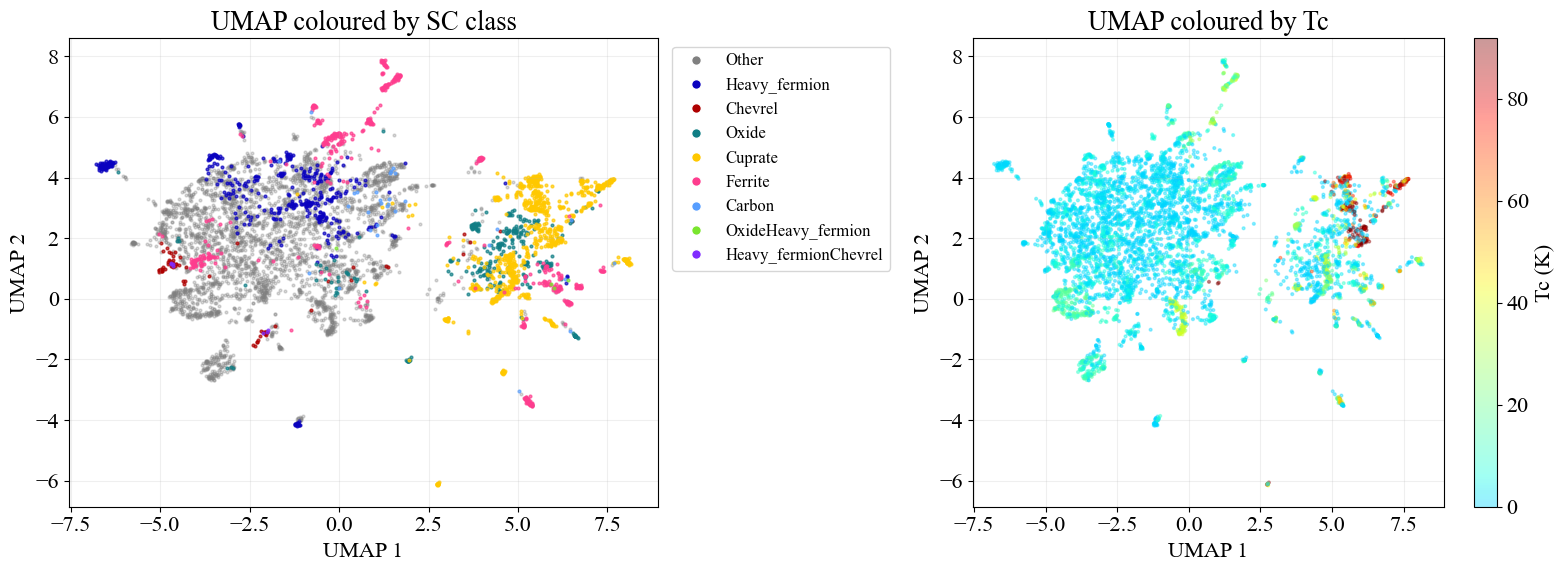

Saved: umap_3dsc.png


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_wchemCIF)
print(f"\nFeature matrix ready: {X_scaled.shape}")

# ── 6. Run UMAP ───────────────────────────────────────────────────────────────
reducer = umap.UMAP(n_components=2, random_state=42,n_neighbors=180, min_dist=0.26)
embedding = reducer.fit_transform(X_scaled)
print("UMAP done.")

# ── 7. Plot — colored by sc_class ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: colour by superconductor class ---
unique_classes = [c for c in sc_class.fillna('Unknown').unique() if c != 'Other']
unique_classes = ['Other'] + unique_classes          # Other goes first (bottom layer)

color_map = {cls: css[i] for i, cls in enumerate(unique_classes)}
sc_class_filled = sc_class.fillna('Unknown')

# Plot Other first (background), then all other classes on top
for cls in unique_classes:
    mask = sc_class_filled == cls
    axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                    c=color_map[cls], label=cls,
                    s=4, alpha=0.3 if cls == 'Other' else 0.7)

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=color_map[cls], markersize=7, label=cls)
           for cls in unique_classes]
axes[0].legend(handles=handles, fontsize=12, bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].set_title('UMAP coloured by SC class')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# --- Right: colour by Tc (critical temperature) ---
sc = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                     c=tc, cmap=jet_trimmed, s=4, alpha=0.4,
                     vmin=0, vmax=tc.quantile(0.99))  # clip outliers
plt.colorbar(sc, ax=axes[1], label='Tc (K)')
axes[1].set_title('UMAP coloured by Tc')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig('umap_3dsc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_3dsc.png")

# ── 8. Save embedding for later use ───────────────────────────────────────────
# out = df[['formula_sc', 'tc', 'sc_class', 'crystal_system_2']].copy()
# out['umap_x'] = embedding[:, 0]
# out['umap_y'] = embedding[:, 1]
# out.to_csv('umap_embedding.csv', index=False)
# print("Saved: umap_embedding.csv")

141 141

RANDOM FOREST FEATURE IMPORTANCE

R² for UMAP1 prediction: 0.995
R² for UMAP2 prediction: 0.993

Top 10 features driving UMAP axis 1:
  max_electronegativity                         0.3384  ███████████████████████████████████████████████████████████████████
  O                                             0.2779  ███████████████████████████████████████████████████████
  std_radius                                    0.1246  ████████████████████████
  formation_energy_per_atom_2                   0.0357  ███████
  min_electronegativity                         0.0220  ████
  min_radius                                    0.0160  ███
  mean_period                                   0.0152  ███
  In                                            0.0119  ██
  std_period                                    0.0112  ██
  latc_2                                        0.0082  █

Top 10 features driving UMAP axis 2:
  max_radius                                    0.2031  █████████████████████████

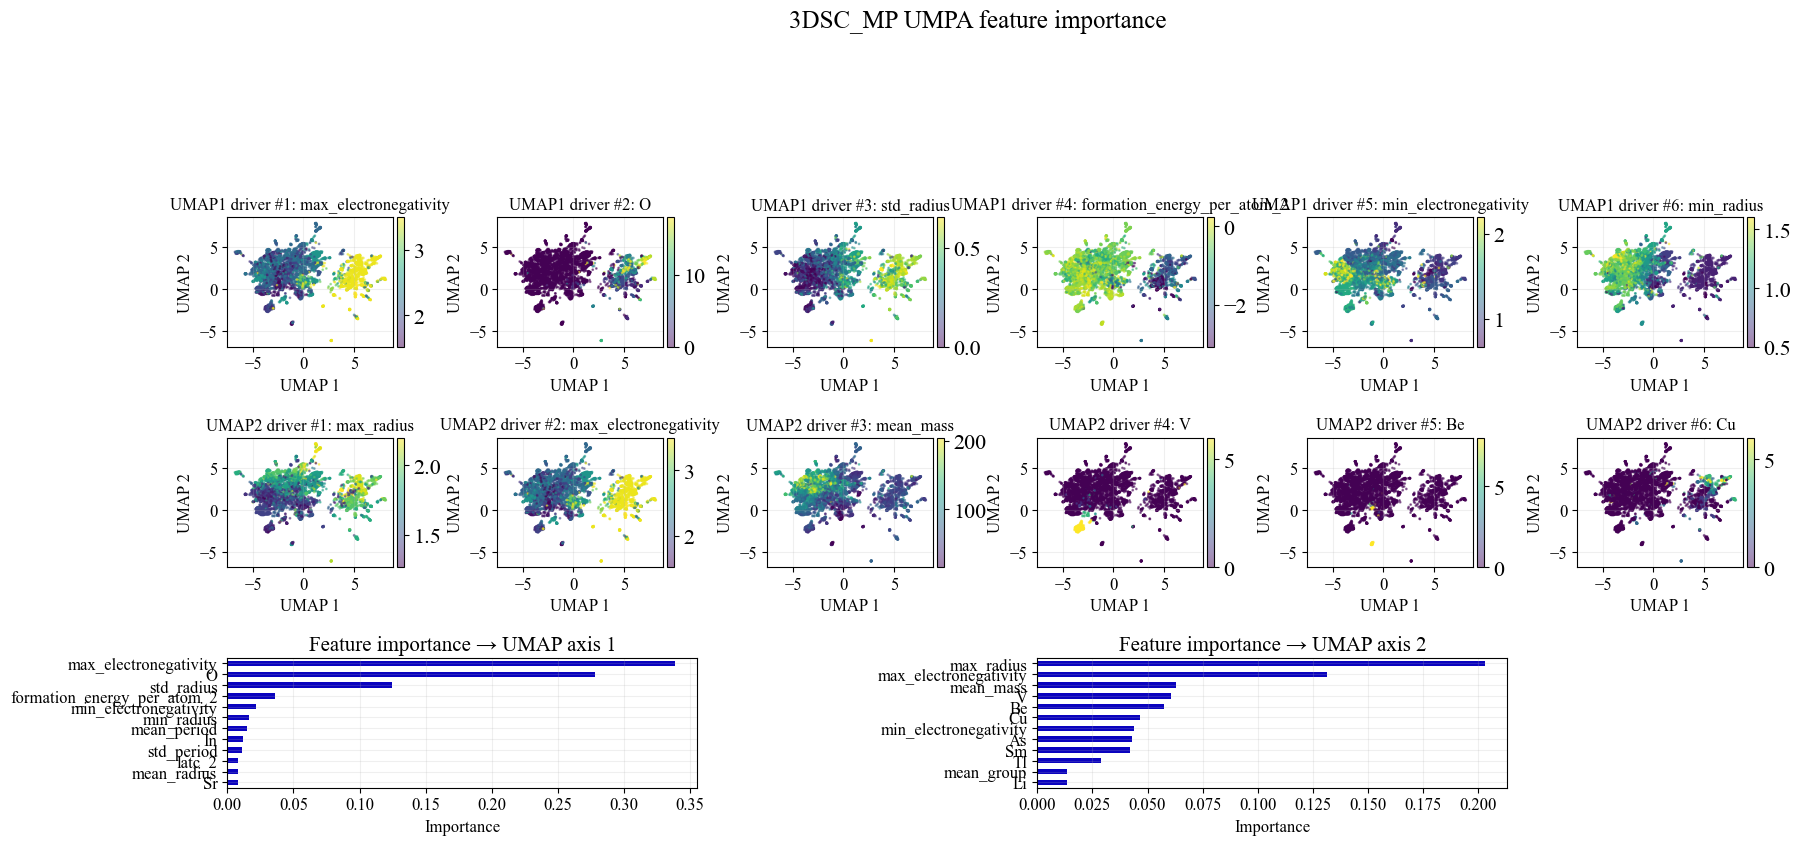


Saved: umap_interpretation.png
Saved: umap_feature_importance.csv

Full summary table:
                             RF_importance_axis1  RF_importance_axis2
max_electronegativity                     0.3384               0.1314
O                                         0.2779               0.0014
std_radius                                0.1246               0.0051
formation_energy_per_atom_2               0.0357               0.0045
min_electronegativity                     0.0220               0.0437
min_radius                                0.0160               0.0112
mean_period                               0.0152               0.0035
In                                        0.0119               0.0004
std_period                                0.0112               0.0050
latc_2                                    0.0082               0.0041
mean_radius                               0.0078               0.0031
Sr                                        0.0078               0.0004
ex

In [30]:
# Build X and feature_cols in one go so they ALWAYS match
from sklearn.ensemble import RandomForestRegressor
from matplotlib import gridspec

feature_cols_new = df_wchemCIF.select_dtypes(include='number').columns.tolist()
X = df_wchemCIF[feature_cols_new].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

print(X_scaled.shape[1], len(feature_cols_new))  # must be equal

# embedding = reducer.fit_transform(X_scaled) #X_scaled

umap1 = embedding[:, 0]
umap2 = embedding[:, 1]

# ── 3. Random Forest feature importance for each axis ─────────────────────────
print("\n" + "=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

rf1 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf1.fit(X_scaled, umap1)
imp1 = pd.Series(rf1.feature_importances_, index=feature_cols_new).sort_values(ascending=False)

rf2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf2.fit(X_scaled, umap2)
imp2 = pd.Series(rf2.feature_importances_, index=feature_cols_new).sort_values(ascending=False)

print(f"\nR² for UMAP1 prediction: {rf1.score(X_scaled, umap1):.3f}")
print(f"R² for UMAP2 prediction: {rf2.score(X_scaled, umap2):.3f}")

print("\nTop 10 features driving UMAP axis 1:")
for feat, val in imp1.head(10).items():
    bar = '█' * int(val * 200)
    print(f"  {feat:<45} {val:.4f}  {bar}")

print("\nTop 10 features driving UMAP axis 2:")
for feat, val in imp2.head(10).items():
    bar = '█' * int(val * 200)
    print(f"  {feat:<45} {val:.4f}  {bar}")

# ── 4. Plot ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(6, 6, figure=fig, hspace=0.7, wspace=0.35)

# Helper: scatter coloured by a feature
def scatter_feature(ax, feat_vals, label, cmap='viridis', vmin=None, vmax=None):
    sc = ax.scatter(umap1, umap2, c=feat_vals, cmap=cmap, s=1, alpha=0.5,
                    vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, pad=0.02)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.tick_params(labelsize=12)

# Row 0: top RF features for axis 1
top1 = imp1.head(6).index.tolist()
for i, feat in enumerate(top1):
    ax = fig.add_subplot(gs[0, i])
    scatter_feature(ax, X[feat],
                    f"UMAP1 driver #{i+1}: {feat}",
                    vmin=X[feat].quantile(0.01),
                    vmax=X[feat].quantile(0.99))

# Row 1: top RF features for axis 2
top2 = imp2.head(6).index.tolist()
for i, feat in enumerate(top2):
    ax = fig.add_subplot(gs[1, i])
    scatter_feature(ax, X[feat],
                    f"UMAP2 driver #{i+1}: {feat}",
                    vmin=X[feat].quantile(0.01),
                    vmax=X[feat].quantile(0.99))

# Row 2: feature importance bar charts
ax_bar1 = fig.add_subplot(gs[2, :2])
imp1.head(12).plot.barh(ax=ax_bar1)
ax_bar1.invert_yaxis()
ax_bar1.set_title('Feature importance → UMAP axis 1', fontsize=15)
ax_bar1.set_xlabel('Importance', fontsize=12)
ax_bar1.tick_params(labelsize=12)

ax_bar2 = fig.add_subplot(gs[2, 3:-1])
imp2.head(12).plot.barh(ax=ax_bar2)
ax_bar2.invert_yaxis()
ax_bar2.set_title('Feature importance → UMAP axis 2', fontsize=15)
ax_bar2.set_xlabel('Importance', fontsize=12)
ax_bar2.tick_params(labelsize=12)

plt.suptitle('3DSC_MP UMPA feature importance', fontsize=18, y=1.01)
plt.savefig('umap_interpretation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: umap_interpretation.png")

# ── 5. Summary table ──────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'RF_importance_axis1': imp1,
    'RF_importance_axis2': imp2,
}).round(4)
summary.to_csv('umap_feature_importance.csv')
print("Saved: umap_feature_importance.csv")
print("\nFull summary table:")
print(summary.sort_values('RF_importance_axis1', ascending=False).to_string())

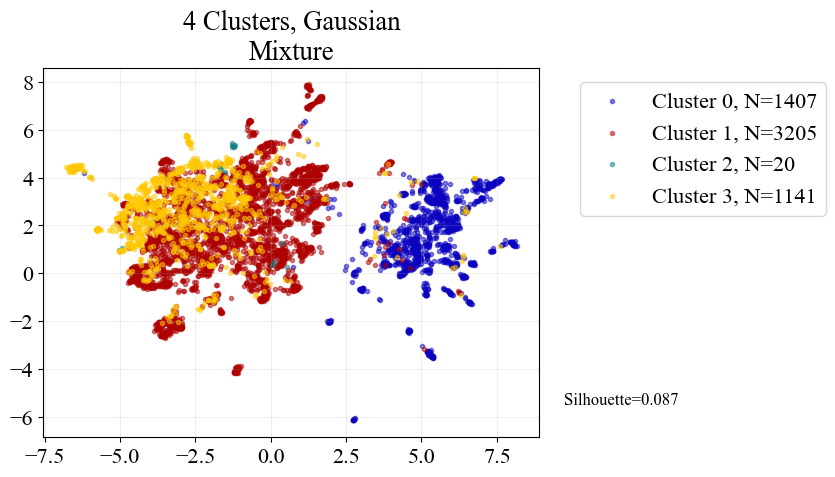

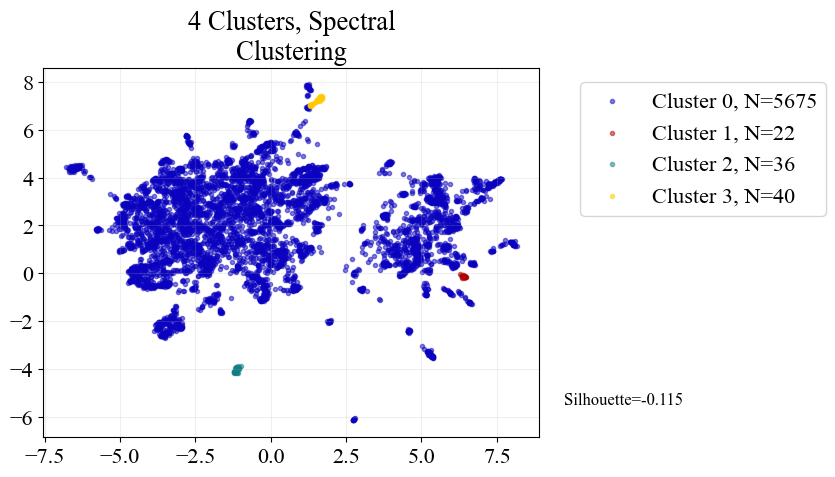

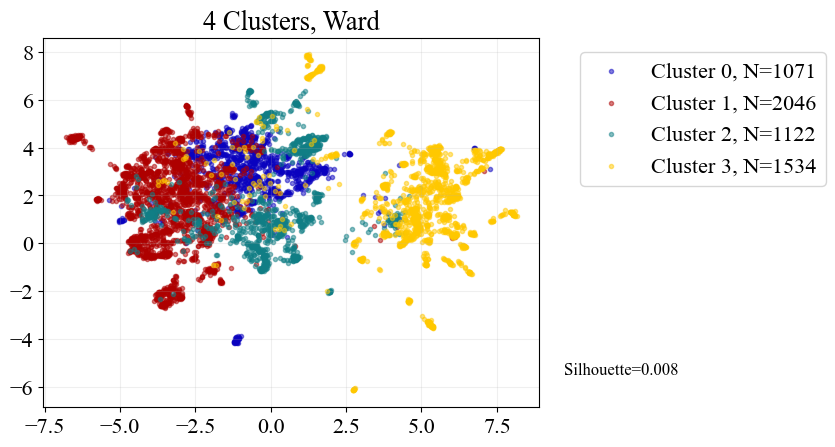

5773
1
(5772, 2)


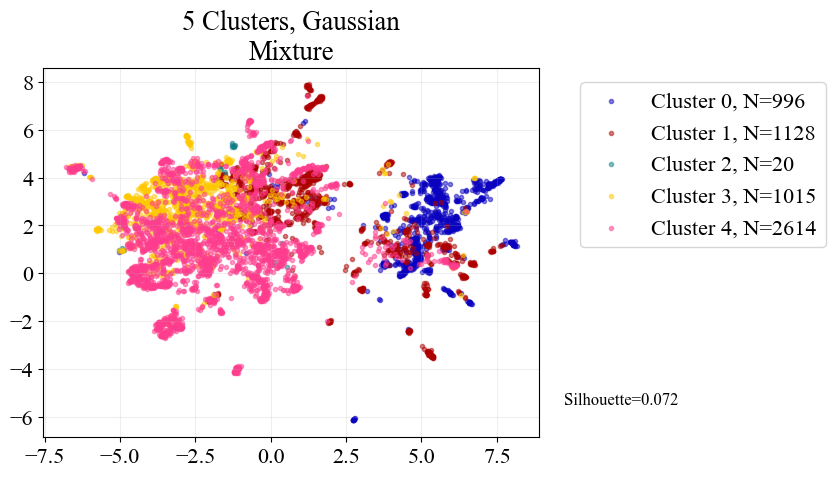

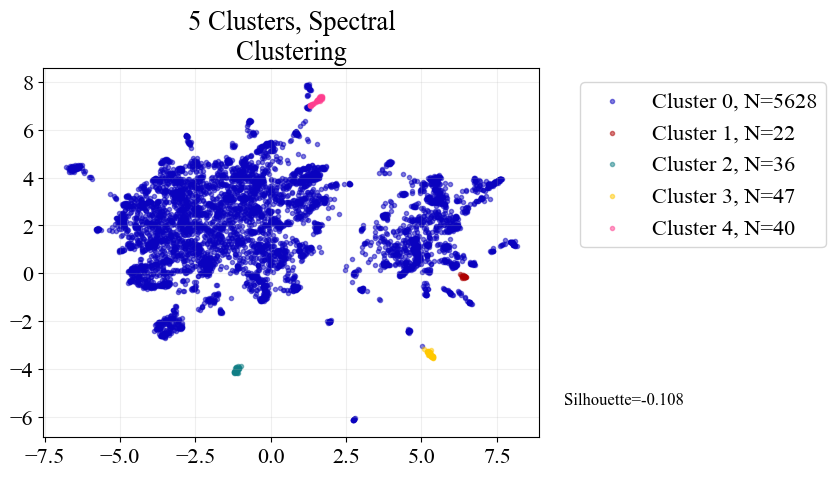

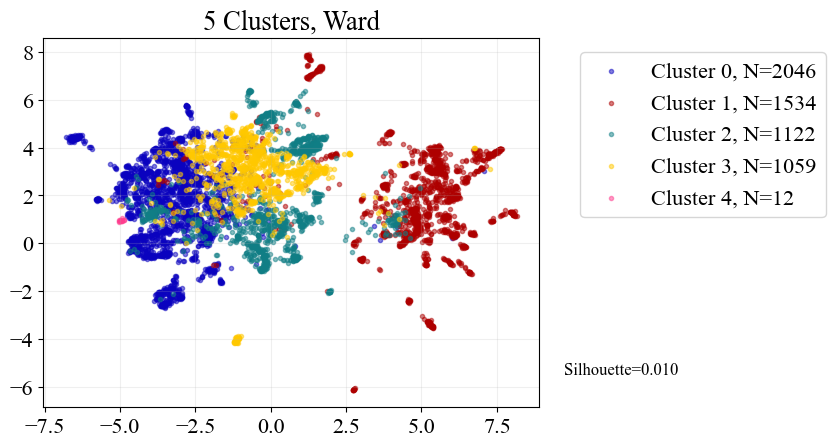

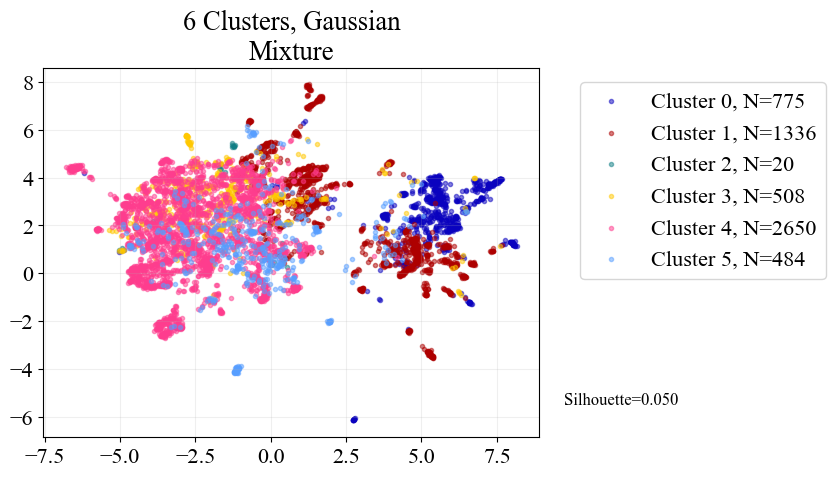

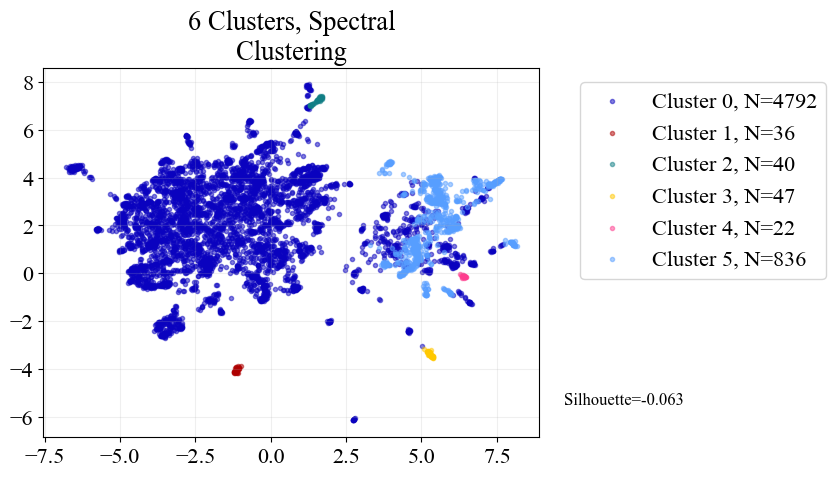

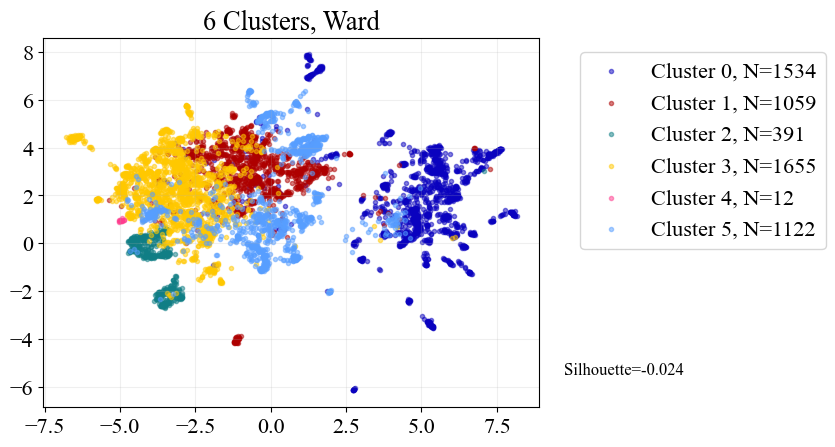

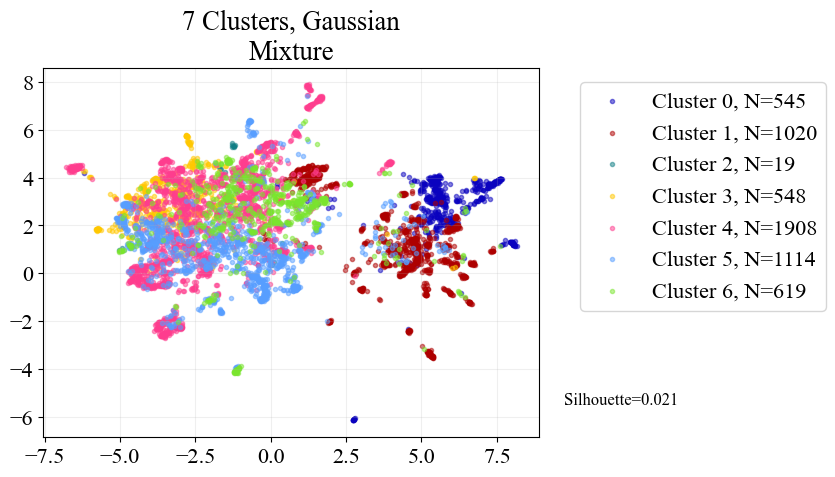

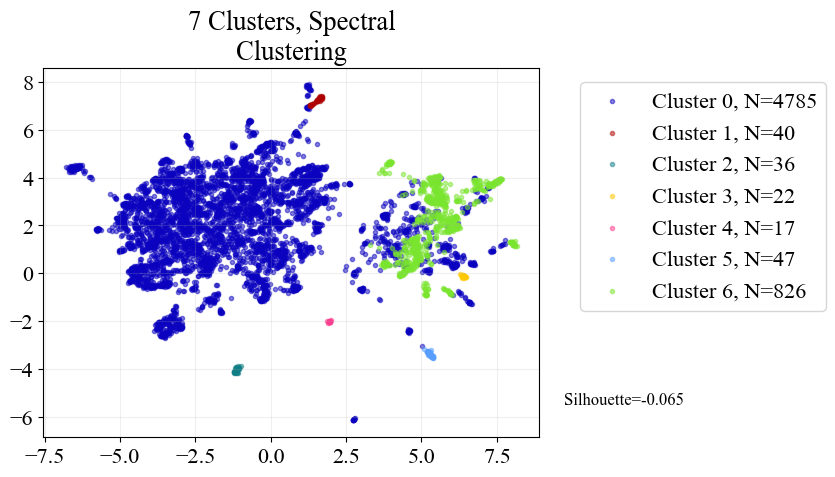

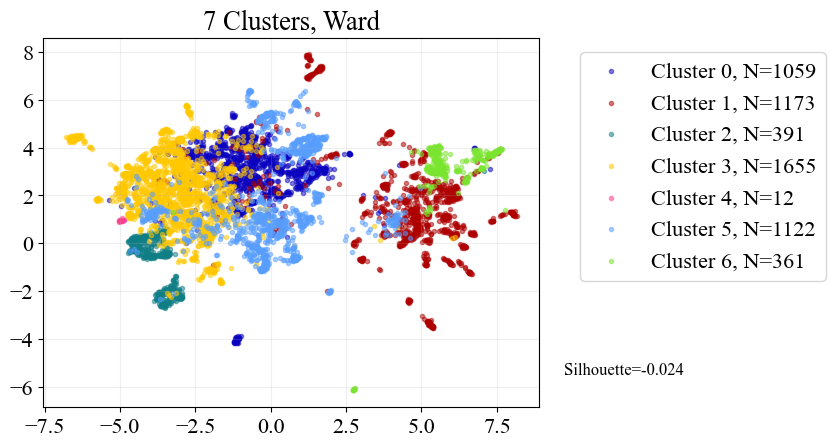

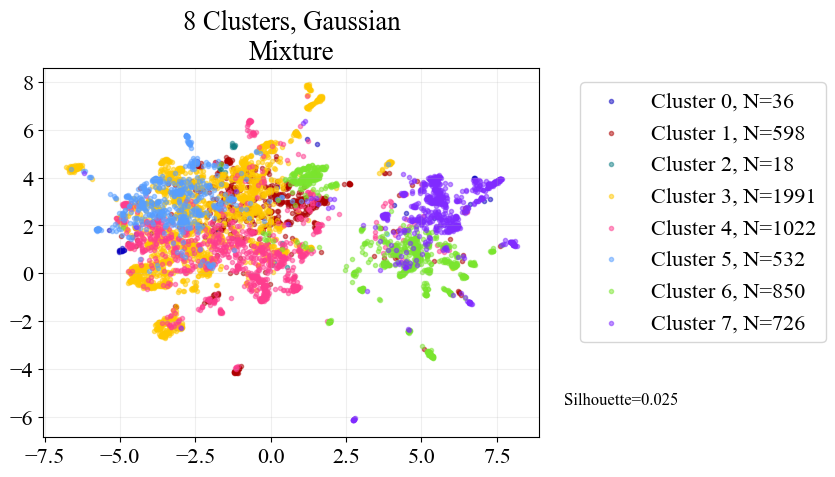

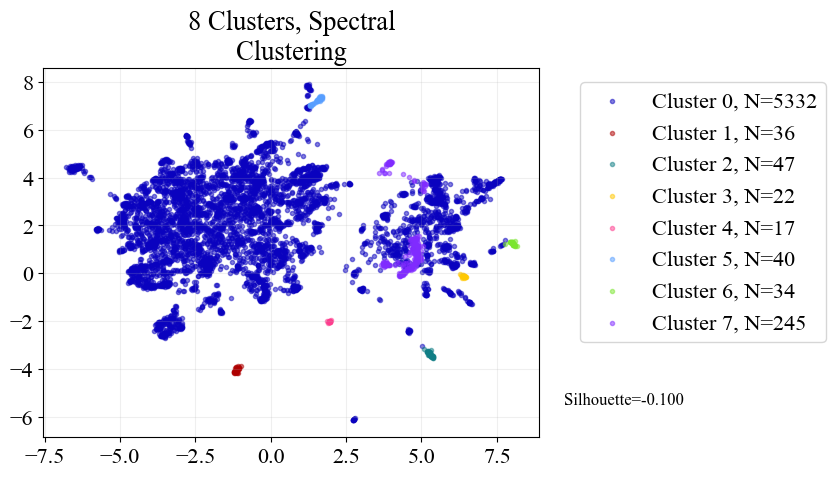

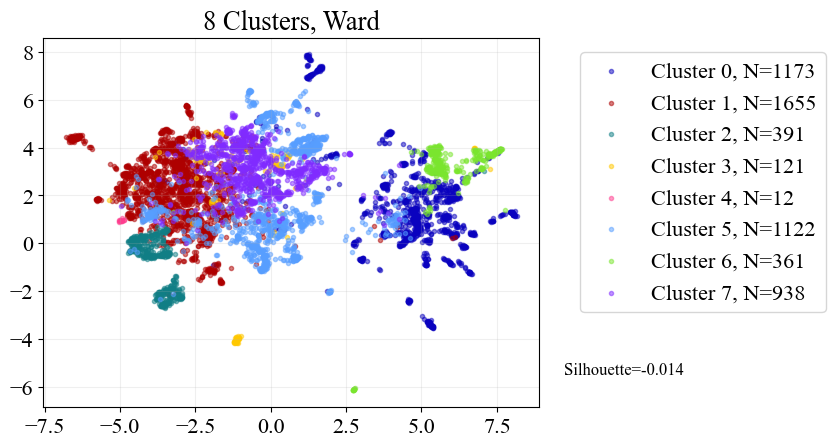

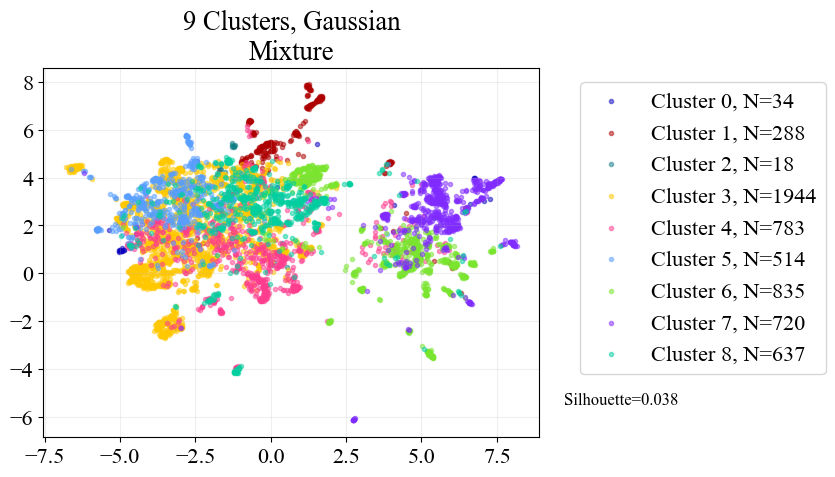

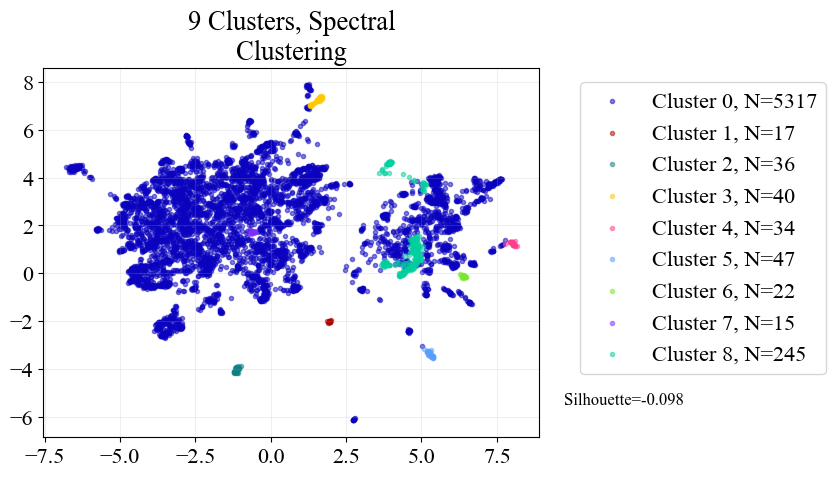

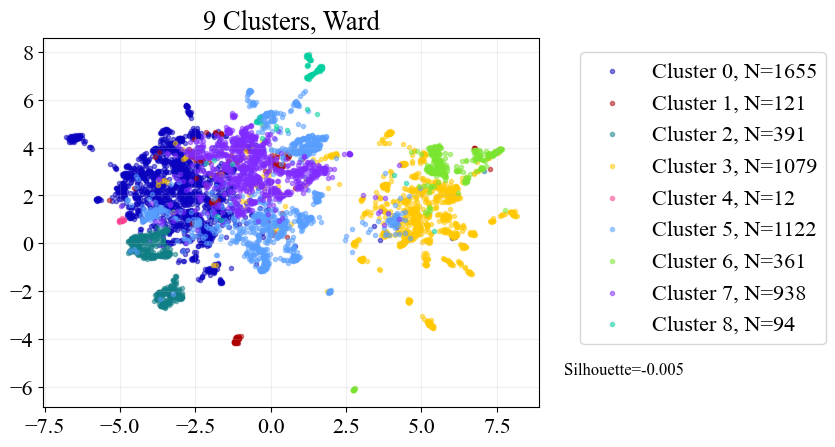

In [51]:
from sklearn import cluster, datasets, mixture
import time
import warnings
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import silhouette_score, mutual_info_score



ncluss = [4,5,6,7,8,9]
for N in ncluss:
    X = X_scaled #X_std #y

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=N, include_self=False
    )
    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

    gmm = mixture.GaussianMixture(
            n_components=N,
            covariance_type="full",
            random_state=42,
        )

    spectral = cluster.SpectralClustering(
        n_clusters=N,
        eigen_solver="arpack",
        affinity="nearest_neighbors",
        random_state=42,
    )
    ward = cluster.AgglomerativeClustering(
        n_clusters=N, linkage="ward", connectivity=None)
    
    bandwidth = cluster.estimate_bandwidth(X, quantile=0.2)
    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)

    clustering_algorithms = (("Gaussian\nMixture", gmm), ("Spectral\nClustering", spectral), ("Ward", ward)) #,("MeanShift", ms))

    

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        # catch warnings related to kneighbors_graph
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="the number of connected components of the "
                + "connectivity matrix is [0-9]{1,2}"
                + " > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning,
            )
            warnings.filterwarnings(
                "ignore",
                message="Graph is not fully connected, spectral embedding"
                + " may not work as expected.",
                category=UserWarning,
                )
            algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        mask = y_pred != -1  # exclude noise
        score = silhouette_score(X, y_pred)
        plt.figure()
        plt.title(f'{N} Clusters, {name}')
        for i in np.unique(y_pred):
            k = embedding[y_pred==i]
            plt.scatter(k[:,0], k[:,1], label=f'Cluster {i}, N={np.sum(len(k))}', alpha=0.5, marker='.')
        plt.legend(loc='upper right', bbox_to_anchor=(1.6,0.99))
        plt.text(1.05, 0.1, f'Silhouette={score:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='center')
        plt.show()

        if name=="Ward" and N==4:
            # y_pred_xx = y_pred
            print(ward.n_leaves_)      # number of leaves (data points)
            print(ward.n_connected_components_)
            print(ward.children_.shape)  # (n_merges, 2) — the merge tree)

    plt.show()

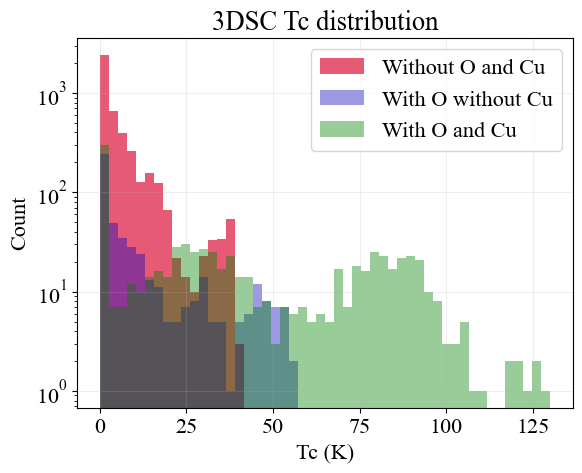

In [58]:
withcu = []

for i in range(len(tc)):
    if df_wchemCIF['O'].iloc[i]!=0:
        if df_wchemCIF['Cu'].iloc[i]==0:
            withcu.append(1)
        else: withcu.append(2)
        # print(f"High Tc without Cu: {formula[i]}, Tc={tc[i]} K")
        
    else: withcu.append(0)

tc_array = np.array(tc)
withcu_array = np.array(withcu)

plt.hist(tc[withcu_array==0], bins=50, alpha=0.7, range=(0,130), label='Without O and Cu', color='crimson')
plt.hist(tc[withcu_array==1], bins=50, alpha=0.4, range=(0,130),label='With O without Cu')
plt.hist(tc[withcu_array==2], bins=50, alpha=0.4, range=(0,130),label='With O and Cu', color='green')
plt.xlabel('Tc (K)')
plt.ylabel('Count')
plt.title('3DSC Tc distribution')
plt.yscale('log')
plt.legend()

In [ ]:

for i in range(len(tc)):
    if df_wchemCIF['Cu'].iloc[i]!=0:
        if df_wchemCIF['O'].iloc[i]==0:
            print(f"Without O but with Cu: {formula[i]}, Tc={tc[i]} K")

High Tc without O but with Cu: Al1Cu1, Tc=3.45 K
High Tc without O but with Cu: Al1Cu1Zr1, Tc=0.0 K
High Tc without O but with Cu: Al1Cu2Zr1, Tc=0.0 K
High Tc without O but with Cu: Al2.06Cu1, Tc=0.65 K
High Tc without O but with Cu: Al2Cu1, Tc=1.02 K
High Tc without O but with Cu: Al4Cu9, Tc=0.0 K
High Tc without O but with Cu: As1Cu1, Tc=0.0 K
High Tc without O but with Cu: As1Cu3, Tc=0.0 K
High Tc without O but with Cu: As2Cu1, Tc=0.0 K
High Tc without O but with Cu: Au0.25Cu0.75, Tc=0.0 K
High Tc without O but with Cu: Au0.5Cu0.5, Tc=0.0 K
High Tc without O but with Cu: Ba8Cu4Si42, Tc=2.9 K
High Tc without O but with Cu: Be3Cu1, Tc=0.0 K
High Tc without O but with Cu: Bi1Cu1, Tc=1.8 K
High Tc without O but with Cu: Bi1Cu1Mg1, Tc=0.0 K
High Tc without O but with Cu: Br2Cu1, Tc=0.0 K
High Tc without O but with Cu: C1Cu0.67Nb2S2, Tc=4.85 K
High Tc without O but with Cu: Ca1Cu5, Tc=0.0 K
High Tc without O but with Cu: Cd0.04Cu0.96S2, Tc=1.3 K
High Tc without O but with Cu: Cd0.06Cu0.94

In [70]:
import matplotlib.colors as mcolors
import numpy as np

# Get the jet_trimmed colors
jet_colors = plt.cm.viridis(np.linspace(1/3, 1.0, 255))

# Prepend grey for 0
grey = np.array([[0.7, 0.7, 0.7, 1.0]])  # RGBA grey
all_colors = np.vstack([grey, jet_colors])

jet_grey = mcolors.LinearSegmentedColormap.from_list('jet_grey', all_colors)

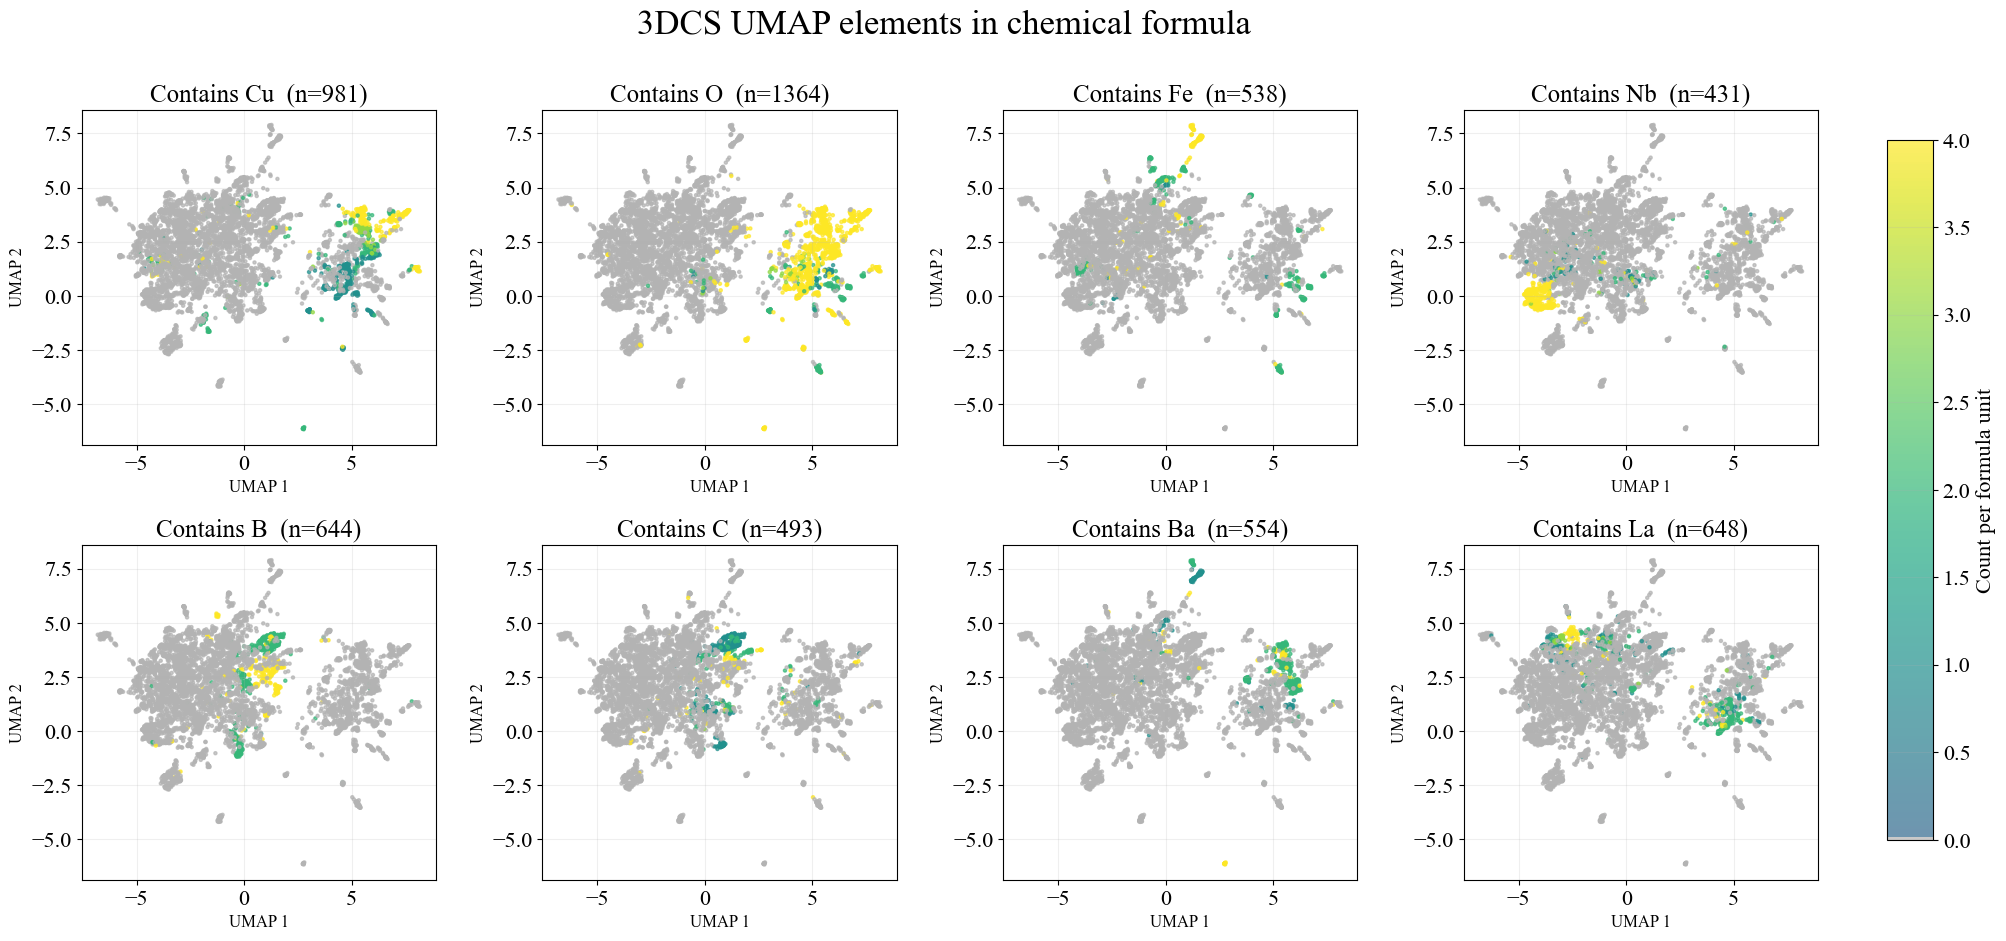

In [73]:
import re

# Choose your elements of interest
highlight_els = ['Cu', 'O','Fe', 'Nb', 'B', 'C', 'Ba', 'La']

fig, axes = plt.subplots(2, 4, figsize=(23, 10), gridspec_kw={'wspace': 0.3, 'hspace': 0.3})
axes = axes.flatten()

for i, el in enumerate(highlight_els):

    pl=axes[i].scatter(embedding[:, 0], embedding[:, 1], s=5, alpha=0.7, c=df_wchemCIF[el], cmap=jet_grey, vmax=4)
    
    axes[i].set_title(f'Contains {el}  (n={np.count_nonzero(df_wchemCIF[el].iloc[:])})', fontsize=18)
    axes[i].set_xlabel('UMAP 1', fontsize=12)
    axes[i].set_ylabel('UMAP 2', fontsize=12)

fig.subplots_adjust(right=0.88)  # make room on the right
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(pl, cax=cbar_ax, label='Count per formula unit')
plt.suptitle('3DCS UMAP elements in chemical formula', fontsize=25)
# plt.tight_layout()
plt.savefig('umap_by_element.png', dpi=150, bbox_inches='tight')
plt.show()